# Generating GRAD-CAM heatmaps

In [1]:
from config_file import *
sys.path.append('./problems')
from train import *

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2  # If not installed, install using 'pip install opencv-python'


## loading data and model

In [2]:
# Load and preprocess the data
# Load the label data
labels = pd.read_csv(DATA_DIR + '/fusion_labels.csv')
# Load tabular data and remove unnecessary columns for model input
tab = pd.read_csv(DATA_DIR + '/tab_data.csv')
tab.drop(columns=['A', 'B', 'C', 'id', 'Feature14', 'Feature13', 'Feature12', 'Feature11', 'Feature10'], inplace=True)
# Combine the tabular data and labels into a single DataFrame for training
data = pd.concat([tab, labels], axis=1)
# Apply a transformation to create a new target column 'y'
data['y'] = get_y(data, 'fusion')

seed = set_seed(SEED) # Set the random seed for reproducibility
nas = {"img_fts": IMG_FTS, "tab_fts": TAB_FTS}
print(nas)

{'img_fts': 2, 'tab_fts': 2}


In [3]:
# model
print_problem()
model = multifix_net_test(nas, OUT_SIZE)
loss_fn = nn.BCELoss()

# Split data into training and testing folds
for i, (train_idx, test_idx) in enumerate(split_data(data, seed)):
    if i == BEST_FOLD:
        train_loader, val_loader, test_loader = get_dataloaders(data, train_idx, test_idx, seed)
        #model, loss_fn = initialise_model(i, nas, True) # initialise the model according to prediction type and training procedure
        wts_dir = save_dir = '/export/scratch2/ima/MultiFIX_GECCO25_code/models/Multifeature/fusion_' + TRAINING + '_' + WTS + '_Freeze_' + str(TEMP_FREEZE) + '.pth'
        print(wts_dir)
        model.load_state_dict(torch.load(wts_dir), strict=False)
        loss, auroc, bacc = eval_model(model, test_loader, loss_fn)  # Evaluate the model
        break

Multifeature Problem: OR(AND(circle,A), AND(!triangle, B)); TRAINING =  ft_comp_comp ; INPUT =  fusion ; OUT_SIZE =  1 ; WTS =  single ; TEMP_FREEZE =  False
/export/scratch2/ima/MultiFIX_GECCO25_code/models/Multifeature/fusion_ft_comp_comp_single_Freeze_False.pth


In [4]:
# Check Evaluation Metrics
print(f"*** BEST FOLD METRICS for {TRAINING} ***")
print("* Loss = ", loss)
print("* AUROC = ", auroc)
print("* BAcc = ", bacc)

*** BEST FOLD METRICS for ft_comp_comp ***
* Loss =  0.0554846932401415
* AUROC =  0.9979707792207793
* BAcc =  0.9898538961038961


# Generate Image Explanations with Grad-CAM

## Choosing samples

In [5]:
def binarize_output(y): # helper function to binarize output
    if y < 0.5: y = 0
    elif y >= 0.5: y = 1
    return y

In [6]:
# converting testloader to list  doesn't shuffle between runs
test_loader_list = list(test_loader)

# list of examples to show, no shapes, only c, only c+t, only t, all shapes, only s
select_examples = [[0, 0, 0], [1 ,0, 0], [1, 1, 0], [0, 1, 0], [1, 1, 1], [0, 0, 1]]

In [7]:
# trying to isolate representative examples per model, output is one list of idx used for grad-CAM visualisation below
right_samples = []
wrong_samples = []
idx = []

# for each instance, make a prediction, and see if it is in the example list
# then check if the prediction is wrong or right, to make sure to get one example per sample
for i,(image_tensor, tab, a, b, label) in enumerate(test_loader_list):
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)
    pred = binarize_output(model(*model_input).detach().cpu())

    a_list = a.flatten().tolist()
    for j in select_examples: 
        if a_list == j:         # chcek if a is the same as one of the select examples
            if pred == label and a_list not in right_samples:
                right_samples.append(a_list)
                idx.append(i)

            elif pred != label and a_list not in wrong_samples:
                wrong_samples.append(a_list)
                idx.append(i)

print(f'List of indices: {idx}')

List of indices: [0, 1, 3, 6, 12, 14, 82, 163]


## Comp comp

Multifeature Problem: OR(AND(circle,A), AND(!triangle, B)); TRAINING =  ft_comp_comp ; INPUT =  fusion ; OUT_SIZE =  1 ; WTS =  single ; TEMP_FREEZE =  False
[0, 1, 3, 6, 12, 14, 82, 163]

0
Y = [[1]]
Y_pred = tensor([[0.9874]])
IMG block 1 prediction -> tensor([[0.9996]])
IMG block 2 prediction -> tensor([[0.0074]])
TAB block 1 prediction -> tensor([[0.8116]])
TAB block 2 prediction -> tensor([[0.9225]])
T1 > T2: 0.47148588090902 > 0.3786796505915807
T3 > T4: 0.2715172049256886 > 0.0538340139149515
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


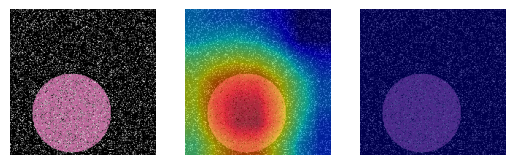

1
Y = [[1]]
Y_pred = tensor([[0.9307]])
IMG block 1 prediction -> tensor([[0.9998]])
IMG block 2 prediction -> tensor([[0.0080]])
TAB block 1 prediction -> tensor([[0.1819]])
TAB block 2 prediction -> tensor([[0.9542]])
T1 > T2: 0.0499005292753698 > 0.1485578393924342
T3 > T4: 0.6725528206034685 > 0.4767644427890656
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


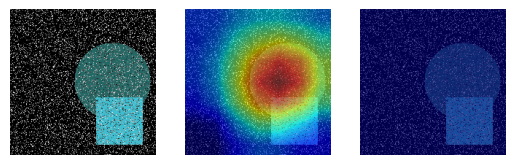

3
Y = [[0]]
Y_pred = tensor([[0.0062]])
IMG block 1 prediction -> tensor([[0.9995]])
IMG block 2 prediction -> tensor([[0.9985]])
TAB block 1 prediction -> tensor([[5.4179e-05]])
TAB block 2 prediction -> tensor([[0.0002]])
T1 > T2: 0.0179022181934309 > 0.7359684709773223
T3 > T4: 0.0981479341894174 > 0.8089433739512141
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


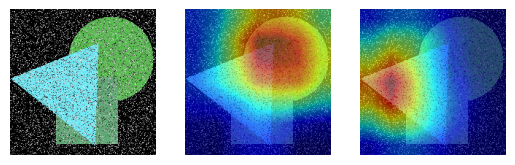

6
Y = [[0]]
Y_pred = tensor([[0.0446]])
IMG block 1 prediction -> tensor([[0.0001]])
IMG block 2 prediction -> tensor([[0.0062]])
TAB block 1 prediction -> tensor([[0.4417]])
TAB block 2 prediction -> tensor([[0.0144]])
T1 > T2: 0.822894298789924 > 0.7606270000038967
T3 > T4: 0.7088324896785989 > 0.9281548359608536
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


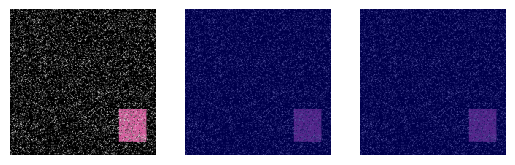

12
Y = [[1]]
Y_pred = tensor([[0.9863]])
IMG block 1 prediction -> tensor([[0.0002]])
IMG block 2 prediction -> tensor([[0.0069]])
TAB block 1 prediction -> tensor([[0.9989]])
TAB block 2 prediction -> tensor([[0.9948]])
T1 > T2: 0.5119749249585483 > 0.1598460579680599
T3 > T4: 0.7253098669155484 > 0.3196641096326529
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


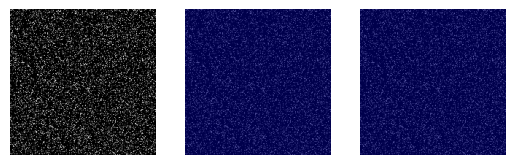

14
Y = [[0]]
Y_pred = tensor([[0.0263]])
IMG block 1 prediction -> tensor([[0.0002]])
IMG block 2 prediction -> tensor([[0.9949]])
TAB block 1 prediction -> tensor([[0.9640]])
TAB block 2 prediction -> tensor([[0.0055]])
T1 > T2: 0.3021346698878361 > 0.169347673819332
T3 > T4: 0.6588502940947246 > 0.9496467372856536
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


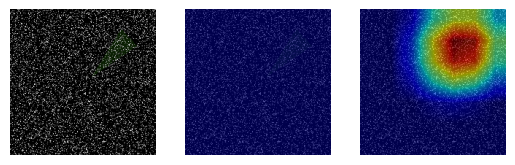

82
Y = [[0]]
Y_pred = tensor([[0.9563]])
IMG block 1 prediction -> tensor([[0.9995]])
IMG block 2 prediction -> tensor([[0.0056]])
TAB block 1 prediction -> tensor([[0.8146]])
TAB block 2 prediction -> tensor([[0.0045]])
T1 > T2: 0.2444977718558427 > 0.2523659018024208
T3 > T4: 0.4161798877403149 > 0.8024429375694436
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


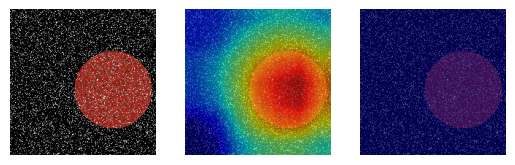

163
Y = [[1]]
Y_pred = tensor([[0.2210]])
IMG block 1 prediction -> tensor([[0.0002]])
IMG block 2 prediction -> tensor([[0.0063]])
TAB block 1 prediction -> tensor([[0.0002]])
TAB block 2 prediction -> tensor([[0.2680]])
T1 > T2: 0.1561278725024304 > 0.7164277284987307
T3 > T4: 0.5664426062485873 > 0.5641228524626333
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


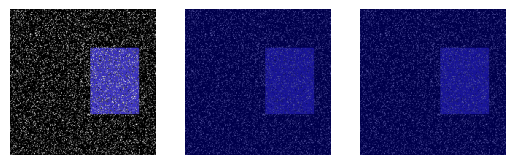

In [8]:
print_problem()
print(f'{idx}\n')

for i in idx:
    print(i)
    image_tensor, tab, a, b, label = test_loader_list[i]
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = 2

    y_pred = model(*model_input).detach().cpu()
    I1_pred = model.img_c_block(*model_input).detach().cpu()
    I2_pred = model.img_t_block(*model_input).detach().cpu() 
    T1_pred = model.tab_a_block(*model_input).detach().cpu()
    T2_pred = model.tab_b_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    t3 = tab[0,3].detach().numpy()
    t4 = tab[0,4].detach().numpy()
    
    # Print results
    print(f"Y = {label}")
    print(f"Y_pred = {y_pred}")
    print(f"IMG block 1 prediction -> {I1_pred}")
    print(f"IMG block 2 prediction -> {I2_pred}")
    print(f"TAB block 1 prediction -> {T1_pred}")
    print(f"TAB block 2 prediction -> {T2_pred}")
    print(f"T1 > T2: {t1} > {t2}")
    print(f"T3 > T4: {t3} > {t4}")

    # Visualize the original image and the heatmap
    plt.subplot(1, num_classes+1, 1)
    plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
    #plt.title('INPUT')
    plt.axis('off')
    
    for j, cls in enumerate([model.img_c_block, model.img_t_block]):
        print(f"Generating Grad-CAM for feature {j + 1} of {num_classes}...")

        # Register hooks in the layer of interest
        target_layer = cls.resnet.layer4[-1]
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        forward_handle = target_layer.register_forward_hook(forward_hook)

        # Forward pass to get the activations and output
        model_output = cls(*model_input)

        # Select the output for the specific class (image feature)
        #class_output = model_output[:, cls]

        # Backward pass to calculate gradients for the selected class
        model.zero_grad()  # Clear previous gradients
        model_output.mean().backward()

        # Compute Grad-CAM
        # Pool the gradients across the channels (global average pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight the activations by the pooled gradients
        weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
        for i in range(weighted_activations.size(1)):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]


        class_score = model_output.sum().detach().cpu().numpy()  # Get the class score
        # Average the channels to get the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # Apply ReLU to the heatmap
        heatmap = F.relu(heatmap)
        
        # Multiply by class score to downscale weak contributions
        heatmap = heatmap.detach().cpu().numpy()

        # Normalize heatmap between 0 and 1 for visualization
        heatmap -= np.min(heatmap)
        if np.max(heatmap) == 0:
            heatmap *= 0
        else: heatmap /= np.max(heatmap)
        
        # Weight heatmap by class score for consistent comparison
        heatmap = heatmap * class_score

        # Resize heatmap to match input image size
        heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

        plt.subplot(1, num_classes+1, j+2)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
        #plt.title(f"#{cls + 1}")
        plt.axis('off')

    #plt.suptitle(f"Grad-CAM for Image {i + 1}")
    plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


## None none

Multifeature Problem: OR(AND(circle,A), AND(!triangle, B)); TRAINING =  ft_none_none ; INPUT =  fusion ; OUT_SIZE =  1 ; WTS =  single ; TEMP_FREEZE =  False
[0, 1, 2, 4, 5, 7, 17, 18, 40, 43, 75, 109]

0
Y = [[1]]
Y_pred = tensor([[0.7646]])
IMG block 1 prediction -> tensor([[0.3741]])
IMG block 2 prediction -> tensor([[0.7536]])
TAB block 1 prediction -> tensor([[0.3329]])
TAB block 2 prediction -> tensor([[0.5535]])
T1 > T2: 0.5722679850530409 > 0.3737178193367133
T3 > T4: 0.5552997507340152 > 0.6425663387203792
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


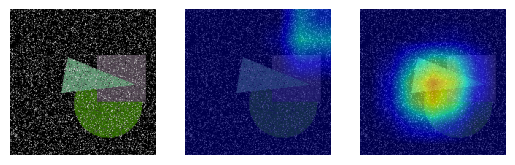

1
Y = [[0]]
Y_pred = tensor([[0.1573]])
IMG block 1 prediction -> tensor([[0.8275]])
IMG block 2 prediction -> tensor([[0.5255]])
TAB block 1 prediction -> tensor([[0.2912]])
TAB block 2 prediction -> tensor([[0.6507]])
T1 > T2: 0.3607954228610627 > 0.2789112105308523
T3 > T4: 0.0005696174167706 > 0.0380044879814622
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


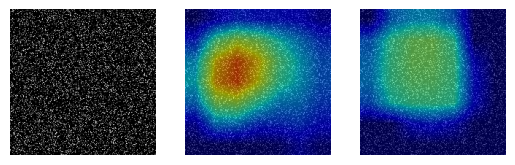

2
Y = [[1]]
Y_pred = tensor([[0.9955]])
IMG block 1 prediction -> tensor([[0.4838]])
IMG block 2 prediction -> tensor([[0.9732]])
TAB block 1 prediction -> tensor([[0.0483]])
TAB block 2 prediction -> tensor([[0.6381]])
T1 > T2: 0.8571249175045673 > 0.1173155641831938
T3 > T4: 0.2712520767618641 > 0.4037927406673345
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


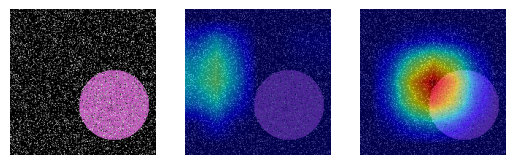

4
Y = [[1]]
Y_pred = tensor([[0.3322]])
IMG block 1 prediction -> tensor([[0.5657]])
IMG block 2 prediction -> tensor([[0.5334]])
TAB block 1 prediction -> tensor([[0.5113]])
TAB block 2 prediction -> tensor([[0.4160]])
T1 > T2: 0.925136396120809 > 0.8147971587996189
T3 > T4: 0.9622775748290447 > 0.9498614395544964
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


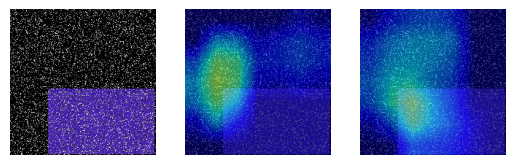

5
Y = [[1]]
Y_pred = tensor([[0.9904]])
IMG block 1 prediction -> tensor([[0.3125]])
IMG block 2 prediction -> tensor([[0.9721]])
TAB block 1 prediction -> tensor([[0.0934]])
TAB block 2 prediction -> tensor([[0.3718]])
T1 > T2: 0.5178423426461387 > 0.1324455020671432
T3 > T4: 0.8923392334821268 > 0.4897180794285108
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


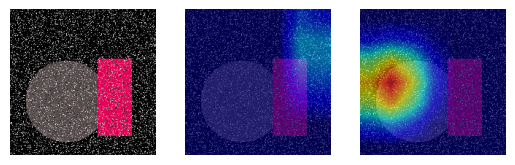

7
Y = [[1]]
Y_pred = tensor([[0.6305]])
IMG block 1 prediction -> tensor([[0.9315]])
IMG block 2 prediction -> tensor([[0.2756]])
TAB block 1 prediction -> tensor([[0.0613]])
TAB block 2 prediction -> tensor([[0.2048]])
T1 > T2: 0.6674103799636817 > 0.1317978624043921
T3 > T4: 0.7163272041185655 > 0.2894060929472011
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


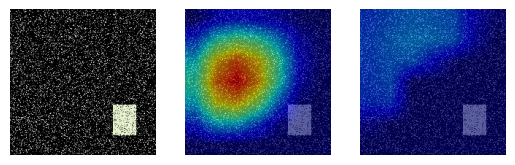

17
Y = [[0]]
Y_pred = tensor([[0.1406]])
IMG block 1 prediction -> tensor([[0.0892]])
IMG block 2 prediction -> tensor([[0.1244]])
TAB block 1 prediction -> tensor([[0.2172]])
TAB block 2 prediction -> tensor([[0.5854]])
T1 > T2: 0.3228295375480875 > 0.2295674446919497
T3 > T4: 0.5068629584873134 > 0.7368531616807855
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


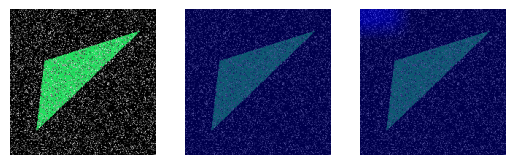

18
Y = [[0]]
Y_pred = tensor([[0.7280]])
IMG block 1 prediction -> tensor([[0.2138]])
IMG block 2 prediction -> tensor([[0.4505]])
TAB block 1 prediction -> tensor([[0.0854]])
TAB block 2 prediction -> tensor([[0.2748]])
T1 > T2: 0.8682803954620041 > 0.1945266935094588
T3 > T4: 0.736479759383793 > 0.1651159684116591
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


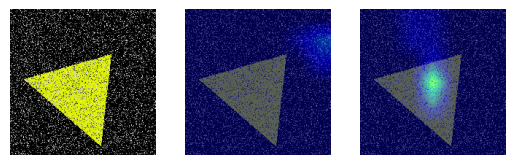

40
Y = [[0]]
Y_pred = tensor([[0.6943]])
IMG block 1 prediction -> tensor([[0.3272]])
IMG block 2 prediction -> tensor([[0.8265]])
TAB block 1 prediction -> tensor([[0.3836]])
TAB block 2 prediction -> tensor([[0.5634]])
T1 > T2: 0.2421098654526366 > 0.322574472619484
T3 > T4: 0.0787384014094656 > 0.4058459588711136
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


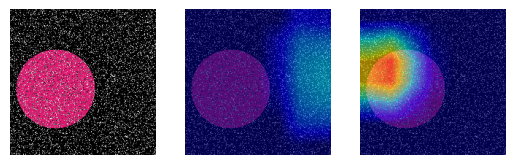

43
Y = [[1]]
Y_pred = tensor([[0.2372]])
IMG block 1 prediction -> tensor([[0.3375]])
IMG block 2 prediction -> tensor([[0.8849]])
TAB block 1 prediction -> tensor([[0.5602]])
TAB block 2 prediction -> tensor([[0.3870]])
T1 > T2: 0.3032221703991922 > 0.9520674909113576
T3 > T4: 0.3621464355630984 > 0.0995496028419083
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


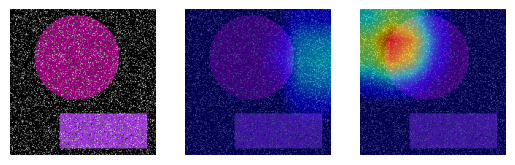

75
Y = [[0]]
Y_pred = tensor([[0.5107]])
IMG block 1 prediction -> tensor([[0.0567]])
IMG block 2 prediction -> tensor([[0.7819]])
TAB block 1 prediction -> tensor([[0.3927]])
TAB block 2 prediction -> tensor([[0.7133]])
T1 > T2: 0.0532373649325327 > 0.1033408509290159
T3 > T4: 0.0984052983193098 > 0.9597770216776176
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


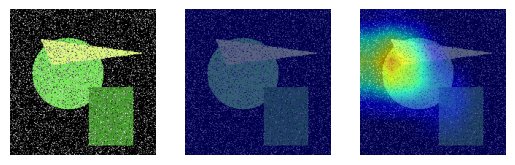

109
Y = [[0]]
Y_pred = tensor([[0.5395]])
IMG block 1 prediction -> tensor([[0.8148]])
IMG block 2 prediction -> tensor([[0.5267]])
TAB block 1 prediction -> tensor([[0.1074]])
TAB block 2 prediction -> tensor([[0.5278]])
T1 > T2: 0.7885455123065187 > 0.0568480764332403
T3 > T4: 0.6969972417249873 > 0.7786953959411034
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


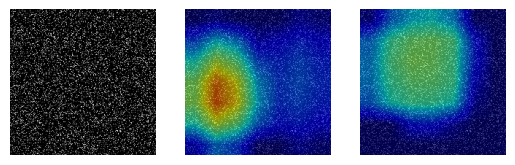

In [8]:
print_problem()
print(f'{idx}\n')

for i in idx:
    print(i)
    image_tensor, tab, a, b, label = test_loader_list[i]
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = 2

    y_pred = model(*model_input).detach().cpu()
    I1_pred = model.img_c_block(*model_input).detach().cpu()
    I2_pred = model.img_t_block(*model_input).detach().cpu() 
    T1_pred = model.tab_a_block(*model_input).detach().cpu()
    T2_pred = model.tab_b_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    t3 = tab[0,3].detach().numpy()
    t4 = tab[0,4].detach().numpy()
    
    # Print results
    print(f"Y = {label}")
    print(f"Y_pred = {y_pred}")
    print(f"IMG block 1 prediction -> {I1_pred}")
    print(f"IMG block 2 prediction -> {I2_pred}")
    print(f"TAB block 1 prediction -> {T1_pred}")
    print(f"TAB block 2 prediction -> {T2_pred}")
    print(f"T1 > T2: {t1} > {t2}")
    print(f"T3 > T4: {t3} > {t4}")

    # Visualize the original image and the heatmap
    plt.subplot(1, num_classes+1, 1)
    plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
    #plt.title('INPUT')
    plt.axis('off')
    
    for j, cls in enumerate([model.img_c_block, model.img_t_block]):
        print(f"Generating Grad-CAM for feature {j + 1} of {num_classes}...")

        # Register hooks in the layer of interest
        target_layer = cls.resnet.layer4[-1]
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        forward_handle = target_layer.register_forward_hook(forward_hook)

        # Forward pass to get the activations and output
        model_output = cls(*model_input)

        # Select the output for the specific class (image feature)
        #class_output = model_output[:, cls]

        # Backward pass to calculate gradients for the selected class
        model.zero_grad()  # Clear previous gradients
        model_output.mean().backward()

        # Compute Grad-CAM
        # Pool the gradients across the channels (global average pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight the activations by the pooled gradients
        weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
        for i in range(weighted_activations.size(1)):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]


        class_score = model_output.sum().detach().cpu().numpy()  # Get the class score
        # Average the channels to get the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # Apply ReLU to the heatmap
        heatmap = F.relu(heatmap)
        
        # Multiply by class score to downscale weak contributions
        heatmap = heatmap.detach().cpu().numpy()

        # Normalize heatmap between 0 and 1 for visualization
        heatmap -= np.min(heatmap)
        if np.max(heatmap) == 0:
            heatmap *= 0
        else: heatmap /= np.max(heatmap)
        
        # Weight heatmap by class score for consistent comparison
        heatmap = heatmap * class_score

        # Resize heatmap to match input image size
        heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

        plt.subplot(1, num_classes+1, j+2)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
        #plt.title(f"#{cls + 1}")
        plt.axis('off')

    #plt.suptitle(f"Grad-CAM for Image {i + 1}")
    plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


## Part none

Multifeature Problem: OR(AND(circle,A), AND(!triangle, B)); TRAINING =  ft_part_none ; INPUT =  fusion ; OUT_SIZE =  1 ; WTS =  single ; TEMP_FREEZE =  False
[0, 1, 2, 3, 4, 5, 7, 11, 15, 17, 18, 43]

0
Y = [[1]]
Y_pred = tensor([[0.1913]])
IMG block 1 prediction -> tensor([[0.4788]])
IMG block 2 prediction -> tensor([[0.2094]])
TAB block 1 prediction -> tensor([[0.9733]])
TAB block 2 prediction -> tensor([[0.9113]])
T1 > T2: 0.5722679850530409 > 0.3737178193367133
T3 > T4: 0.5552997507340152 > 0.6425663387203792
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


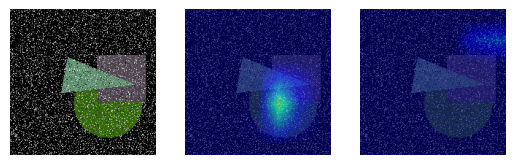

1
Y = [[0]]
Y_pred = tensor([[0.9727]])
IMG block 1 prediction -> tensor([[0.4584]])
IMG block 2 prediction -> tensor([[0.6481]])
TAB block 1 prediction -> tensor([[0.9547]])
TAB block 2 prediction -> tensor([[0.3056]])
T1 > T2: 0.3607954228610627 > 0.2789112105308523
T3 > T4: 0.0005696174167706 > 0.0380044879814622
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


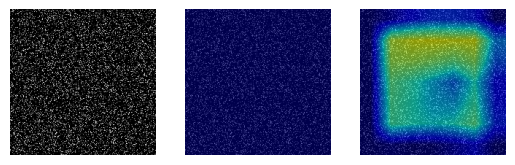

2
Y = [[1]]
Y_pred = tensor([[0.9764]])
IMG block 1 prediction -> tensor([[0.9549]])
IMG block 2 prediction -> tensor([[0.2397]])
TAB block 1 prediction -> tensor([[1.0000]])
TAB block 2 prediction -> tensor([[0.8537]])
T1 > T2: 0.8571249175045673 > 0.1173155641831938
T3 > T4: 0.2712520767618641 > 0.4037927406673345
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


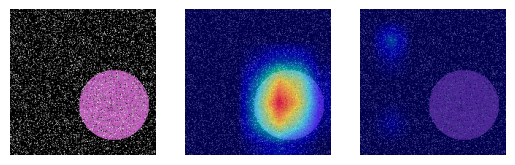

3
Y = [[0]]
Y_pred = tensor([[0.1368]])
IMG block 1 prediction -> tensor([[0.9536]])
IMG block 2 prediction -> tensor([[0.0110]])
TAB block 1 prediction -> tensor([[0.0028]])
TAB block 2 prediction -> tensor([[0.0985]])
T1 > T2: 0.0127386015995843 > 0.61913356412323
T3 > T4: 0.0989459646481409 > 0.1483895355169587
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


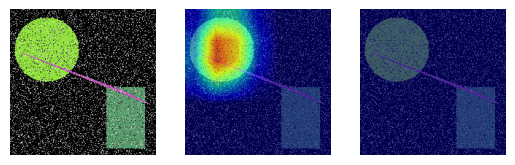

4
Y = [[1]]
Y_pred = tensor([[0.8697]])
IMG block 1 prediction -> tensor([[0.4380]])
IMG block 2 prediction -> tensor([[0.6550]])
TAB block 1 prediction -> tensor([[0.2860]])
TAB block 2 prediction -> tensor([[0.3944]])
T1 > T2: 0.925136396120809 > 0.8147971587996189
T3 > T4: 0.9622775748290447 > 0.9498614395544964
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


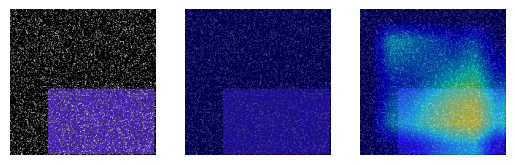

5
Y = [[1]]
Y_pred = tensor([[0.9841]])
IMG block 1 prediction -> tensor([[0.9151]])
IMG block 2 prediction -> tensor([[0.2015]])
TAB block 1 prediction -> tensor([[0.9961]])
TAB block 2 prediction -> tensor([[0.2383]])
T1 > T2: 0.5178423426461387 > 0.1324455020671432
T3 > T4: 0.8923392334821268 > 0.4897180794285108
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


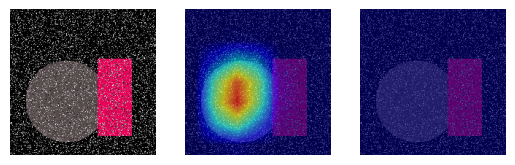

7
Y = [[1]]
Y_pred = tensor([[0.2071]])
IMG block 1 prediction -> tensor([[0.4528]])
IMG block 2 prediction -> tensor([[0.0714]])
TAB block 1 prediction -> tensor([[0.9989]])
TAB block 2 prediction -> tensor([[0.2329]])
T1 > T2: 0.6674103799636817 > 0.1317978624043921
T3 > T4: 0.7163272041185655 > 0.2894060929472011
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


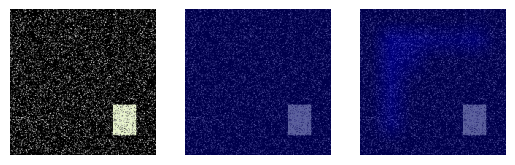

11
Y = [[1]]
Y_pred = tensor([[0.4075]])
IMG block 1 prediction -> tensor([[0.8104]])
IMG block 2 prediction -> tensor([[0.2257]])
TAB block 1 prediction -> tensor([[0.4709]])
TAB block 2 prediction -> tensor([[0.8209]])
T1 > T2: 0.4781379595073937 > 0.363892774321953
T3 > T4: 0.8034974713723212 > 0.6947656127138895
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


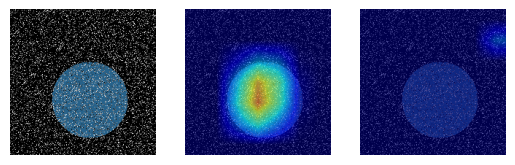

15
Y = [[1]]
Y_pred = tensor([[0.9541]])
IMG block 1 prediction -> tensor([[0.4586]])
IMG block 2 prediction -> tensor([[0.6566]])
TAB block 1 prediction -> tensor([[0.0605]])
TAB block 2 prediction -> tensor([[0.0625]])
T1 > T2: 0.3801299286660544 > 0.6221922694904162
T3 > T4: 0.8934060265156545 > 0.1583914721013889
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


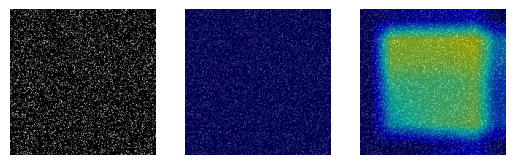

17
Y = [[0]]
Y_pred = tensor([[0.1875]])
IMG block 1 prediction -> tensor([[0.4580]])
IMG block 2 prediction -> tensor([[6.6323e-09]])
TAB block 1 prediction -> tensor([[0.9701]])
TAB block 2 prediction -> tensor([[0.7697]])
T1 > T2: 0.3228295375480875 > 0.2295674446919497
T3 > T4: 0.5068629584873134 > 0.7368531616807855
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


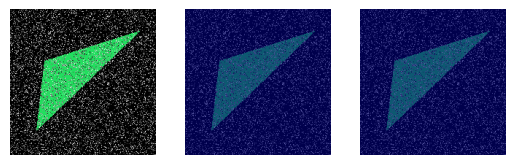

18
Y = [[0]]
Y_pred = tensor([[0.8782]])
IMG block 1 prediction -> tensor([[0.7428]])
IMG block 2 prediction -> tensor([[1.2196e-06]])
TAB block 1 prediction -> tensor([[0.9988]])
TAB block 2 prediction -> tensor([[0.2625]])
T1 > T2: 0.8682803954620041 > 0.1945266935094588
T3 > T4: 0.736479759383793 > 0.1651159684116591
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


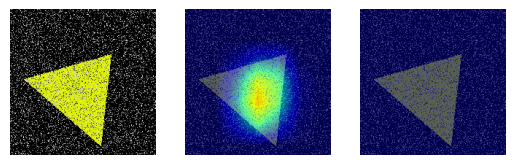

43
Y = [[1]]
Y_pred = tensor([[0.1370]])
IMG block 1 prediction -> tensor([[0.9494]])
IMG block 2 prediction -> tensor([[0.0352]])
TAB block 1 prediction -> tensor([[0.0005]])
TAB block 2 prediction -> tensor([[0.1325]])
T1 > T2: 0.3032221703991922 > 0.9520674909113576
T3 > T4: 0.3621464355630984 > 0.0995496028419083
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


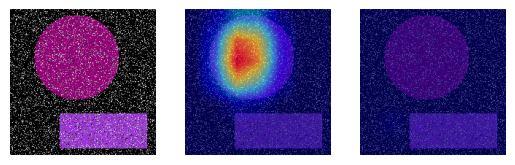

In [12]:
print_problem()
print(f'{idx}\n')

for i in idx:
    print(i)
    image_tensor, tab, a, b, label = test_loader_list[i]
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = 2

    y_pred = model(*model_input).detach().cpu()
    I1_pred = model.img_c_block(*model_input).detach().cpu()
    I2_pred = model.img_t_block(*model_input).detach().cpu() 
    T1_pred = model.tab_a_block(*model_input).detach().cpu()
    T2_pred = model.tab_b_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    t3 = tab[0,3].detach().numpy()
    t4 = tab[0,4].detach().numpy()
    
    # Print results
    print(f"Y = {label}")
    print(f"Y_pred = {y_pred}")
    print(f"IMG block 1 prediction -> {I1_pred}")
    print(f"IMG block 2 prediction -> {I2_pred}")
    print(f"TAB block 1 prediction -> {T1_pred}")
    print(f"TAB block 2 prediction -> {T2_pred}")
    print(f"T1 > T2: {t1} > {t2}")
    print(f"T3 > T4: {t3} > {t4}")

    # Visualize the original image and the heatmap
    plt.subplot(1, num_classes+1, 1)
    plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
    #plt.title('INPUT')
    plt.axis('off')
    
    for j, cls in enumerate([model.img_c_block, model.img_t_block]):
        print(f"Generating Grad-CAM for feature {j + 1} of {num_classes}...")

        # Register hooks in the layer of interest
        target_layer = cls.resnet.layer4[-1]
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        forward_handle = target_layer.register_forward_hook(forward_hook)

        # Forward pass to get the activations and output
        model_output = cls(*model_input)

        # Select the output for the specific class (image feature)
        #class_output = model_output[:, cls]

        # Backward pass to calculate gradients for the selected class
        model.zero_grad()  # Clear previous gradients
        model_output.mean().backward()

        # Compute Grad-CAM
        # Pool the gradients across the channels (global average pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight the activations by the pooled gradients
        weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
        for i in range(weighted_activations.size(1)):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]


        class_score = model_output.sum().detach().cpu().numpy()  # Get the class score
        # Average the channels to get the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # Apply ReLU to the heatmap
        heatmap = F.relu(heatmap)
        
        # Multiply by class score to downscale weak contributions
        heatmap = heatmap.detach().cpu().numpy()

        # Normalize heatmap between 0 and 1 for visualization
        heatmap -= np.min(heatmap)
        if np.max(heatmap) == 0:
            heatmap *= 0
        else: heatmap /= np.max(heatmap)
        
        # Weight heatmap by class score for consistent comparison
        heatmap = heatmap * class_score

        # Resize heatmap to match input image size
        heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

        plt.subplot(1, num_classes+1, j+2)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
        #plt.title(f"#{cls + 1}")
        plt.axis('off')

    #plt.suptitle(f"Grad-CAM for Image {i + 1}")
    plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


## Part part

Multifeature Problem: OR(AND(circle,A), AND(!triangle, B)); TRAINING =  ft_part_part ; INPUT =  fusion ; OUT_SIZE =  1 ; WTS =  single ; TEMP_FREEZE =  False
[0, 1, 3, 4, 7, 9, 12, 13, 14, 43, 115]

0
Y = [[0]]
Y_pred = tensor([[0.0030]])
IMG block 1 prediction -> tensor([[0.0003]])
IMG block 2 prediction -> tensor([[0.9898]])
TAB block 1 prediction -> tensor([[0.0497]])
TAB block 2 prediction -> tensor([[0.2312]])
T1 > T2: 0.3701408855266072 > 0.4286238420970678
T3 > T4: 0.3161532482858075 > 0.3037141387862903
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


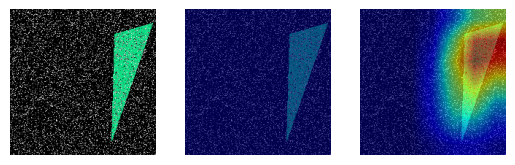

1
Y = [[0]]
Y_pred = tensor([[0.1037]])
IMG block 1 prediction -> tensor([[1.0000]])
IMG block 2 prediction -> tensor([[1.]])
TAB block 1 prediction -> tensor([[0.0868]])
TAB block 2 prediction -> tensor([[0.5719]])
T1 > T2: 0.3868930123267445 > 0.499012664343811
T3 > T4: 0.8951140528845675 > 0.4290137108455464
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


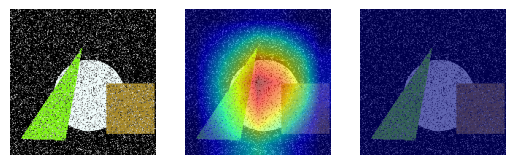

3
Y = [[0]]
Y_pred = tensor([[0.0254]])
IMG block 1 prediction -> tensor([[0.0002]])
IMG block 2 prediction -> tensor([[0.0781]])
TAB block 1 prediction -> tensor([[0.9935]])
TAB block 2 prediction -> tensor([[0.0480]])
T1 > T2: 0.2964909701605218 > 0.0146147205155551
T3 > T4: 0.4836453641618805 > 0.9698255037310616
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


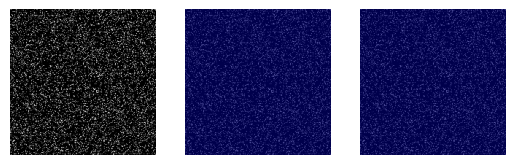

4
Y = [[0]]
Y_pred = tensor([[0.0162]])
IMG block 1 prediction -> tensor([[0.0003]])
IMG block 2 prediction -> tensor([[0.5052]])
TAB block 1 prediction -> tensor([[3.0717e-05]])
TAB block 2 prediction -> tensor([[0.1422]])
T1 > T2: 0.3097249068149077 > 0.9248238134265128
T3 > T4: 0.0505054070301879 > 0.2720251935839619
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


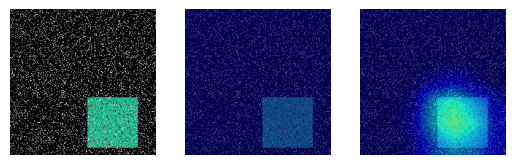

7
Y = [[1]]
Y_pred = tensor([[0.9545]])
IMG block 1 prediction -> tensor([[1.0000]])
IMG block 2 prediction -> tensor([[1.0000]])
TAB block 1 prediction -> tensor([[0.9240]])
TAB block 2 prediction -> tensor([[0.5129]])
T1 > T2: 0.2103825610738409 > 0.1289262976548533
T3 > T4: 0.3154283509241838 > 0.3637107709426226
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


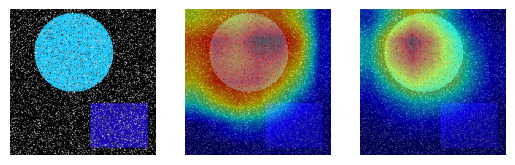

9
Y = [[0]]
Y_pred = tensor([[0.1051]])
IMG block 1 prediction -> tensor([[1.0000]])
IMG block 2 prediction -> tensor([[0.9908]])
TAB block 1 prediction -> tensor([[8.2217e-05]])
TAB block 2 prediction -> tensor([[0.6561]])
T1 > T2: 0.1033548909898831 > 0.8138340674888196
T3 > T4: 0.6906737552086535 > 0.7314387927718887
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


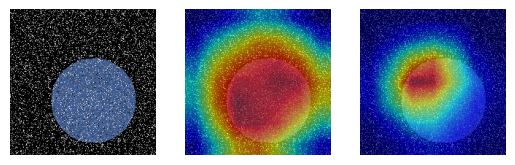

12
Y = [[1]]
Y_pred = tensor([[0.4690]])
IMG block 1 prediction -> tensor([[0.0002]])
IMG block 2 prediction -> tensor([[0.0795]])
TAB block 1 prediction -> tensor([[0.0013]])
TAB block 2 prediction -> tensor([[0.3517]])
T1 > T2: 0.1255356502756268 > 0.4878892941940417
T3 > T4: 0.6424258070755656 > 0.5696041113586421
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


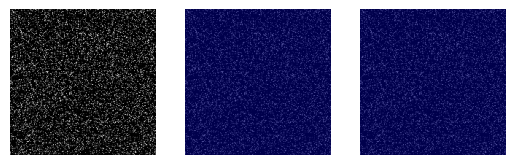

13
Y = [[1]]
Y_pred = tensor([[0.1322]])
IMG block 1 prediction -> tensor([[1.0000]])
IMG block 2 prediction -> tensor([[0.9864]])
TAB block 1 prediction -> tensor([[3.7351e-05]])
TAB block 2 prediction -> tensor([[0.7554]])
T1 > T2: 0.2153982043432382 > 0.8583376386342625
T3 > T4: 0.8028933715613342 > 0.1591462369422428
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


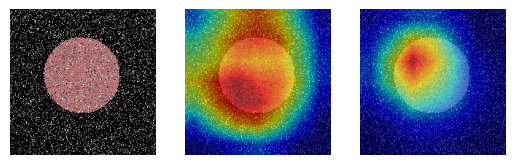

14
Y = [[1]]
Y_pred = tensor([[0.3792]])
IMG block 1 prediction -> tensor([[0.0002]])
IMG block 2 prediction -> tensor([[0.6011]])
TAB block 1 prediction -> tensor([[0.9729]])
TAB block 2 prediction -> tensor([[0.8598]])
T1 > T2: 0.8776996722246968 > 0.7802873423853813
T3 > T4: 0.7560062649157743 > 0.2518730347440954
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


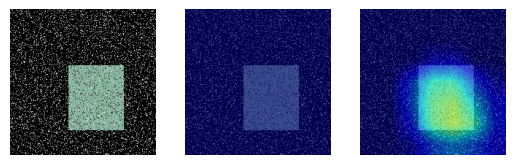

43
Y = [[1]]
Y_pred = tensor([[0.3937]])
IMG block 1 prediction -> tensor([[1.0000]])
IMG block 2 prediction -> tensor([[0.5310]])
TAB block 1 prediction -> tensor([[0.0008]])
TAB block 2 prediction -> tensor([[0.5650]])
T1 > T2: 0.2193707405802608 > 0.5860947340466732
T3 > T4: 0.7749496601910048 > 0.2855078920416467
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


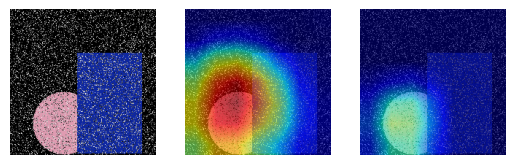

115
Y = [[0]]
Y_pred = tensor([[0.9666]])
IMG block 1 prediction -> tensor([[0.0002]])
IMG block 2 prediction -> tensor([[0.0800]])
TAB block 1 prediction -> tensor([[0.0027]])
TAB block 2 prediction -> tensor([[0.7214]])
T1 > T2: 0.1327075194852194 > 0.570896078395051
T3 > T4: 0.921342132035472 > 0.6488023089252271
Generating Grad-CAM for feature 1 of 2...
Generating Grad-CAM for feature 2 of 2...


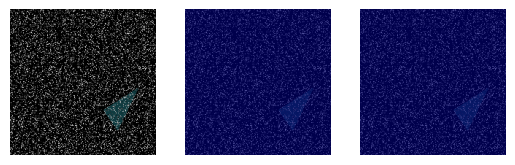

In [22]:
print_problem()
print(f'{idx}\n')

for i in idx:
    print(i)
    image_tensor, tab, a, b, label = test_loader_list[i]
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = 2

    y_pred = model(*model_input).detach().cpu()
    I1_pred = model.img_c_block(*model_input).detach().cpu()
    I2_pred = model.img_t_block(*model_input).detach().cpu() 
    T1_pred = model.tab_a_block(*model_input).detach().cpu()
    T2_pred = model.tab_b_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    t3 = tab[0,3].detach().numpy()
    t4 = tab[0,4].detach().numpy()
    
    # Print results
    print(f"Y = {label}")
    print(f"Y_pred = {y_pred}")
    print(f"IMG block 1 prediction -> {I1_pred}")
    print(f"IMG block 2 prediction -> {I2_pred}")
    print(f"TAB block 1 prediction -> {T1_pred}")
    print(f"TAB block 2 prediction -> {T2_pred}")
    print(f"T1 > T2: {t1} > {t2}")
    print(f"T3 > T4: {t3} > {t4}")

    # Visualize the original image and the heatmap
    plt.subplot(1, num_classes+1, 1)
    plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
    #plt.title('INPUT')
    plt.axis('off')
    
    for j, cls in enumerate([model.img_c_block, model.img_t_block]):
        print(f"Generating Grad-CAM for feature {j + 1} of {num_classes}...")

        # Register hooks in the layer of interest
        target_layer = cls.resnet.layer4[-1]
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        forward_handle = target_layer.register_forward_hook(forward_hook)

        # Forward pass to get the activations and output
        model_output = cls(*model_input)

        # Select the output for the specific class (image feature)
        #class_output = model_output[:, cls]

        # Backward pass to calculate gradients for the selected class
        model.zero_grad()  # Clear previous gradients
        model_output.mean().backward()

        # Compute Grad-CAM
        # Pool the gradients across the channels (global average pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight the activations by the pooled gradients
        weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
        for i in range(weighted_activations.size(1)):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]


        class_score = model_output.sum().detach().cpu().numpy()  # Get the class score
        # Average the channels to get the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # Apply ReLU to the heatmap
        heatmap = F.relu(heatmap)
        
        # Multiply by class score to downscale weak contributions
        heatmap = heatmap.detach().cpu().numpy()

        # Normalize heatmap between 0 and 1 for visualization
        heatmap -= np.min(heatmap)
        if np.max(heatmap) == 0:
            heatmap *= 0
        else: heatmap /= np.max(heatmap)
        
        # Weight heatmap by class score for consistent comparison
        heatmap = heatmap * class_score

        # Resize heatmap to match input image size
        heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

        plt.subplot(1, num_classes+1, j+2)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
        #plt.title(f"#{cls + 1}")
        plt.axis('off')

    #plt.suptitle(f"Grad-CAM for Image {i + 1}")
    plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


# old code

## Comp Comp old? sandbox

In [23]:
print_problem()
positive_counter = 0
negative_counter = 0

for i in range(20):
    image_tensor, tab, a, b, label = next(iterator)
    if a in select_examples:
        if positive_counter == 0:
            # Process image for display
            img = image_tensor[0].permute(1, 2, 0).detach().numpy()
            # Get predictions
            model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

            # Global variables to store gradients and activations
            gradients = None
            activations = None

            # Hook to capture gradients
            def backward_hook(module, grad_input, grad_output):
                global gradients
                gradients = grad_output[0]  # Extract gradients
                #print("Gradients size ->", gradients.size())

            # Hook to capture activations (feature maps)
            def forward_hook(module, input, output):
                global activations
                activations = output  # Save the activations
                #print("Activations size ->", activations.size())

            # chose target layer according to grad cam repo
            # https://github.com/jacobgil/pytorch-grad-cam
            # Resnet18 and 50: model.layer4[-1]

            # Loop through all "classes" (engineered image features)
            num_classes = 2

            y_pred = model(*model_input).detach().cpu()
            if y_pred < 0.5: y_pred_bin = 0
            elif y_pred_bin >= 0.5: y_pred_bin = 1
            
            if y_pred == label:
                positive_counter += 1
            else:
                negative_counter += 1

            I1_pred = model.img_c_block(*model_input).detach().cpu()
            I2_pred = model.img_t_block(*model_input).detach().cpu() 
            T1_pred = model.tab_a_block(*model_input).detach().cpu()
            T2_pred = model.tab_b_block(*model_input).detach().cpu()
            label = label.detach().numpy()
            t1 = tab[0,1].detach().numpy()
            t2 = tab[0,2].detach().numpy()
            t3 = tab[0,3].detach().numpy()
            t4 = tab[0,4].detach().numpy()
            
            # Print results
            print(f"Y = {label}")
            print(f"Y_pred = {y_pred}")
            print(f"IMG block 1 prediction -> {I1_pred}")
            print(f"IMG block 2 prediction -> {I2_pred}")
            print(f"TAB block 1 prediction -> {T1_pred}")
            print(f"TAB block 2 prediction -> {T2_pred}")
            print(f"T1 > T2: {t1} > {t2}")
            print(f"T3 > T4: {t3} > {t4}")

            # Visualize the original image and the heatmap
            plt.subplot(1, num_classes+1, 1)
            plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
            #plt.title('INPUT')
            plt.axis('off')
            
            for j, cls in enumerate([model.img_c_block, model.img_t_block]):
                print(f"Generating Grad-CAM for feature {j + 1} of {num_classes}...")

                # Register hooks in the layer of interest
                target_layer = cls.resnet.layer4[-1]
                backward_handle = target_layer.register_full_backward_hook(backward_hook)
                forward_handle = target_layer.register_forward_hook(forward_hook)

                # Forward pass to get the activations and output
                model_output = cls(*model_input)

                # Select the output for the specific class (image feature)
                #class_output = model_output[:, cls]

                # Backward pass to calculate gradients for the selected class
                model.zero_grad()  # Clear previous gradients
                model_output.mean().backward()

                # Compute Grad-CAM
                # Pool the gradients across the channels (global average pooling)
                pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

                # Weight the activations by the pooled gradients
                weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
                for i in range(weighted_activations.size(1)):
                    weighted_activations[:, i, :, :] *= pooled_gradients[i]


                class_score = model_output.sum().detach().cpu().numpy()  # Get the class score
                # Average the channels to get the heatmap
                heatmap = torch.mean(weighted_activations, dim=1).squeeze()

                # Apply ReLU to the heatmap
                heatmap = F.relu(heatmap)
                
                # Multiply by class score to downscale weak contributions
                heatmap = heatmap.detach().cpu().numpy()

                # Normalize heatmap between 0 and 1 for visualization
                heatmap -= np.min(heatmap)
                if np.max(heatmap) == 0:
                    heatmap *= 0
                else: heatmap /= np.max(heatmap)
                
                # Weight heatmap by class score for consistent comparison
                heatmap = heatmap * class_score

                # Resize heatmap to match input image size
                heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

                plt.subplot(1, num_classes+1, j+2)
                plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
                plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
                #plt.title(f"#{cls + 1}")
                plt.axis('off')

            #plt.suptitle(f"Grad-CAM for Image {i + 1}")
            plt.show()
            # Remove hooks after collecting gradients and activations for this class
            backward_handle.remove()
            forward_handle.remove()

        elif negative_counter == 0:
            # Process image for display
            img = image_tensor[0].permute(1, 2, 0).detach().numpy()
            # Get predictions
            model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

            # Global variables to store gradients and activations
            gradients = None
            activations = None

            # Hook to capture gradients
            def backward_hook(module, grad_input, grad_output):
                global gradients
                gradients = grad_output[0]  # Extract gradients
                #print("Gradients size ->", gradients.size())

            # Hook to capture activations (feature maps)
            def forward_hook(module, input, output):
                global activations
                activations = output  # Save the activations
                #print("Activations size ->", activations.size())

            # chose target layer according to grad cam repo
            # https://github.com/jacobgil/pytorch-grad-cam
            # Resnet18 and 50: model.layer4[-1]

            # Loop through all "classes" (engineered image features)
            num_classes = 2

            y_pred = model(*model_input).detach().cpu()
            if y_pred < 0.5: y_pred_bin = 0
            elif y_pred_bin >= 0.5: y_pred_bin = 1
            
            if y_pred == label:
                positive_counter += 1
            else:
                negative_counter += 1

            I1_pred = model.img_c_block(*model_input).detach().cpu()
            I2_pred = model.img_t_block(*model_input).detach().cpu() 
            T1_pred = model.tab_a_block(*model_input).detach().cpu()
            T2_pred = model.tab_b_block(*model_input).detach().cpu()
            label = label.detach().numpy()
            t1 = tab[0,1].detach().numpy()
            t2 = tab[0,2].detach().numpy()
            t3 = tab[0,3].detach().numpy()
            t4 = tab[0,4].detach().numpy()
            
            # Print results
            print(f"Y = {label}")
            print(f"Y_pred = {y_pred}")
            print(f"IMG block 1 prediction -> {I1_pred}")
            print(f"IMG block 2 prediction -> {I2_pred}")
            print(f"TAB block 1 prediction -> {T1_pred}")
            print(f"TAB block 2 prediction -> {T2_pred}")
            print(f"T1 > T2: {t1} > {t2}")
            print(f"T3 > T4: {t3} > {t4}")

            # Visualize the original image and the heatmap
            plt.subplot(1, num_classes+1, 1)
            plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
            #plt.title('INPUT')
            plt.axis('off')
            
            for j, cls in enumerate([model.img_c_block, model.img_t_block]):
                print(f"Generating Grad-CAM for feature {j + 1} of {num_classes}...")

                # Register hooks in the layer of interest
                target_layer = cls.resnet.layer4[-1]
                backward_handle = target_layer.register_full_backward_hook(backward_hook)
                forward_handle = target_layer.register_forward_hook(forward_hook)

                # Forward pass to get the activations and output
                model_output = cls(*model_input)

                # Select the output for the specific class (image feature)
                #class_output = model_output[:, cls]

                # Backward pass to calculate gradients for the selected class
                model.zero_grad()  # Clear previous gradients
                model_output.mean().backward()

                # Compute Grad-CAM
                # Pool the gradients across the channels (global average pooling)
                pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

                # Weight the activations by the pooled gradients
                weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
                for i in range(weighted_activations.size(1)):
                    weighted_activations[:, i, :, :] *= pooled_gradients[i]


                class_score = model_output.sum().detach().cpu().numpy()  # Get the class score
                # Average the channels to get the heatmap
                heatmap = torch.mean(weighted_activations, dim=1).squeeze()

                # Apply ReLU to the heatmap
                heatmap = F.relu(heatmap)
                
                # Multiply by class score to downscale weak contributions
                heatmap = heatmap.detach().cpu().numpy()

                # Normalize heatmap between 0 and 1 for visualization
                heatmap -= np.min(heatmap)
                if np.max(heatmap) == 0:
                    heatmap *= 0
                else: heatmap /= np.max(heatmap)
                
                # Weight heatmap by class score for consistent comparison
                heatmap = heatmap * class_score

                # Resize heatmap to match input image size
                heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

                plt.subplot(1, num_classes+1, j+2)
                plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
                plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
                #plt.title(f"#{cls + 1}")
                plt.axis('off')

            #plt.suptitle(f"Grad-CAM for Image {i + 1}")
            plt.show()
            # Remove hooks after collecting gradients and activations for this class
            backward_handle.remove()
            forward_handle.remove()
        
        else:
            pass

Multifeature Problem: OR(AND(circle,A), AND(!triangle, B)); TRAINING =  ft_part_part ; INPUT =  fusion ; OUT_SIZE =  1 ; WTS =  single ; TEMP_FREEZE =  False


NameError: name 'iterator' is not defined

## None none

In [ ]:
iterator = iter(test_loader)
print_problem()

for i in range(10):
    print(i)
    image_tensor, tab, a, b, label = next(iterator)
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = 2

    y_pred = model(*model_input).detach().cpu()
    I1_pred = model.img_c_block(*model_input).detach().cpu()
    I2_pred = model.img_t_block(*model_input).detach().cpu() 
    T1_pred = model.tab_a_block(*model_input).detach().cpu()
    T2_pred = model.tab_b_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    t3 = tab[0,3].detach().numpy()
    t4 = tab[0,4].detach().numpy()
    
    # Print results
    print(f"Y = {label}")
    print(f"Y_pred = {y_pred}")
    print(f"IMG block 1 prediction -> {I1_pred}")
    print(f"IMG block 2 prediction -> {I2_pred}")
    print(f"TAB block 1 prediction -> {T1_pred}")
    print(f"TAB block 2 prediction -> {T2_pred}")
    print(f"T1 > T2: {t1} > {t2}")
    print(f"T3 > T4: {t3} > {t4}")

    # Visualize the original image and the heatmap
    plt.subplot(1, num_classes+1, 1)
    plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
    #plt.title('INPUT')
    plt.axis('off')
    
    for j, cls in enumerate([model.img_c_block, model.img_t_block]):
        print(f"Generating Grad-CAM for feature {j + 1} of {num_classes}...")

        # Register hooks in the layer of interest
        target_layer = cls.resnet.layer4[-1]
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        forward_handle = target_layer.register_forward_hook(forward_hook)

        # Forward pass to get the activations and output
        model_output = cls(*model_input)

        # Select the output for the specific class (image feature)
        #class_output = model_output[:, cls]

        # Backward pass to calculate gradients for the selected class
        model.zero_grad()  # Clear previous gradients
        model_output.mean().backward()

        # Compute Grad-CAM
        # Pool the gradients across the channels (global average pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight the activations by the pooled gradients
        weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
        for i in range(weighted_activations.size(1)):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]


        class_score = model_output.sum().detach().cpu().numpy()  # Get the class score
        # Average the channels to get the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # Apply ReLU to the heatmap
        heatmap = F.relu(heatmap)
        
        # Multiply by class score to downscale weak contributions
        heatmap = heatmap.detach().cpu().numpy()

        # Normalize heatmap between 0 and 1 for visualization
        heatmap -= np.min(heatmap)
        if np.max(heatmap) == 0:
            heatmap *= 0
        else: heatmap /= np.max(heatmap)
        
        # Weight heatmap by class score for consistent comparison
        heatmap = heatmap * class_score

        # Resize heatmap to match input image size
        heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

        plt.subplot(1, num_classes+1, j+2)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
        #plt.title(f"#{cls + 1}")
        plt.axis('off')

    #plt.suptitle(f"Grad-CAM for Image {i + 1}")
    plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


## part part

In [ ]:
iterator = iter(test_loader)
print_problem()

for i in range(10):
    image_tensor, tab, a, b, label = next(iterator)
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = 2

    y_pred = model(*model_input).detach().cpu()
    I1_pred = model.img_c_block(*model_input).detach().cpu()
    I2_pred = model.img_t_block(*model_input).detach().cpu() 
    T1_pred = model.tab_a_block(*model_input).detach().cpu()
    T2_pred = model.tab_b_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    t3 = tab[0,3].detach().numpy()
    t4 = tab[0,4].detach().numpy()
    
    # Print results
    print(f"Y = {label}")
    print(f"Y_pred = {y_pred}")
    print(f"IMG block 1 prediction -> {I1_pred}")
    print(f"IMG block 2 prediction -> {I2_pred}")
    print(f"TAB block 1 prediction -> {T1_pred}")
    print(f"TAB block 2 prediction -> {T2_pred}")
    print(f"T1 > T2: {t1} > {t2}")
    print(f"T3 > T4: {t3} > {t4}")

    # Visualize the original image and the heatmap
    plt.subplot(1, num_classes+1, 1)
    plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
    #plt.title('INPUT')
    plt.axis('off')
    
    for j, cls in enumerate([model.img_c_block, model.img_t_block]):
        print(f"Generating Grad-CAM for feature {j + 1} of {num_classes}...")

        # Register hooks in the layer of interest
        target_layer = cls.resnet.layer4[-1]
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        forward_handle = target_layer.register_forward_hook(forward_hook)

        # Forward pass to get the activations and output
        model_output = cls(*model_input)

        # Select the output for the specific class (image feature)
        #class_output = model_output[:, cls]

        # Backward pass to calculate gradients for the selected class
        model.zero_grad()  # Clear previous gradients
        model_output.mean().backward()

        # Compute Grad-CAM
        # Pool the gradients across the channels (global average pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight the activations by the pooled gradients
        weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
        for i in range(weighted_activations.size(1)):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]


        class_score = model_output.sum().detach().cpu().numpy()  # Get the class score
        # Average the channels to get the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # Apply ReLU to the heatmap
        heatmap = F.relu(heatmap)
        
        # Multiply by class score to downscale weak contributions
        heatmap = heatmap.detach().cpu().numpy()

        # Normalize heatmap between 0 and 1 for visualization
        heatmap -= np.min(heatmap)
        if np.max(heatmap) == 0:
            heatmap *= 0
        else: heatmap /= np.max(heatmap)
        
        # Weight heatmap by class score for consistent comparison
        heatmap = heatmap * class_score

        # Resize heatmap to match input image size
        heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

        plt.subplot(1, num_classes+1, j+2)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
        #plt.title(f"#{cls + 1}")
        plt.axis('off')

    #plt.suptitle(f"Grad-CAM for Image {i + 1}")
    plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


## Part none

In [ ]:
iterator = iter(test_loader)
print_problem()

for i in range(10):
    image_tensor, tab, a, b, label = next(iterator)
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = 2

    y_pred = model(*model_input).detach().cpu()
    I1_pred = model.img_c_block(*model_input).detach().cpu()
    I2_pred = model.img_t_block(*model_input).detach().cpu() 
    T1_pred = model.tab_a_block(*model_input).detach().cpu()
    T2_pred = model.tab_b_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    t3 = tab[0,3].detach().numpy()
    t4 = tab[0,4].detach().numpy()
    
    # Print results
    print(f"Y = {label}")
    print(f"Y_pred = {y_pred}")
    print(f"IMG block 1 prediction -> {I1_pred}")
    print(f"IMG block 2 prediction -> {I2_pred}")
    print(f"TAB block 1 prediction -> {T1_pred}")
    print(f"TAB block 2 prediction -> {T2_pred}")
    print(f"T1 > T2: {t1} > {t2}")
    print(f"T3 > T4: {t3} > {t4}")

    # Visualize the original image and the heatmap
    plt.subplot(1, num_classes+1, 1)
    plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
    #plt.title('INPUT')
    plt.axis('off')
    
    for j, cls in enumerate([model.img_c_block, model.img_t_block]):
        print(f"Generating Grad-CAM for feature {j + 1} of {num_classes}...")

        # Register hooks in the layer of interest
        target_layer = cls.resnet.layer4[-1]
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        forward_handle = target_layer.register_forward_hook(forward_hook)

        # Forward pass to get the activations and output
        model_output = cls(*model_input)

        # Select the output for the specific class (image feature)
        #class_output = model_output[:, cls]

        # Backward pass to calculate gradients for the selected class
        model.zero_grad()  # Clear previous gradients
        model_output.mean().backward()

        # Compute Grad-CAM
        # Pool the gradients across the channels (global average pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight the activations by the pooled gradients
        weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
        for i in range(weighted_activations.size(1)):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]


        class_score = model_output.sum().detach().cpu().numpy()  # Get the class score
        # Average the channels to get the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # Apply ReLU to the heatmap
        heatmap = F.relu(heatmap)
        
        # Multiply by class score to downscale weak contributions
        heatmap = heatmap.detach().cpu().numpy()

        # Normalize heatmap between 0 and 1 for visualization
        heatmap -= np.min(heatmap)
        if np.max(heatmap) == 0:
            heatmap *= 0
        else: heatmap /= np.max(heatmap)
        
        # Weight heatmap by class score for consistent comparison
        heatmap = heatmap * class_score

        # Resize heatmap to match input image size
        heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

        plt.subplot(1, num_classes+1, j+2)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
        #plt.title(f"#{cls + 1}")
        plt.axis('off')

    #plt.suptitle(f"Grad-CAM for Image {i + 1}")
    plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


In [ ]:
# print problem
for i in range(10):
    image_tensor, tab, a, b, label = next(iterator)
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # Register hooks in the layer of interest
    target_layer = model.img_c_block.resnet.layer4[-1]
    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = model.img_c_block(*model_input).size(1)

    y_pred = model(*model_input).detach().cpu()
    a_pred = model.img_c_block(*model_input).detach().cpu()
    b_pred = model.tab_a_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t1 = tab[0,1].detach().numpy()
    t2 = tab[0,2].detach().numpy()
    
    # Print results
    print(f"Y = {label}")
    print(f"Y_pred = {y_pred}")
    print(f"IMG_PRED -> {a_pred}")
    print(f"TAB_PRED -> {b_pred}")
    print(f"T1 > T2: {t1} > {t2}")

    # Visualize the original image and the heatmap
    plt.subplot(1, num_classes+1, 1)
    plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
    #plt.title('INPUT')
    plt.axis('off')
    
    for cls in range(num_classes):
        print(f"Generating Grad-CAM for feature {cls + 1} of {num_classes}...")

        # Register hooks
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        forward_handle = target_layer.register_forward_hook(forward_hook)

        # Forward pass to get the activations and output
        model_output = model.img_c_block(*model_input)

        # Select the output for the specific class (image feature)
        class_output = model_output[:, cls]

        # Backward pass to calculate gradients for the selected class
        model.zero_grad()  # Clear previous gradients
        class_output.mean().backward()

        # Compute Grad-CAM
        # Pool the gradients across the channels (global average pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight the activations by the pooled gradients
        weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
        for i in range(weighted_activations.size(1)):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]


        class_score = class_output.sum().detach().cpu().numpy()  # Get the class score
        # Average the channels to get the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # Apply ReLU to the heatmap
        heatmap = F.relu(heatmap)
        
        # Multiply by class score to downscale weak contributions
        heatmap = heatmap.detach().cpu().numpy()

        # Normalize heatmap between 0 and 1 for visualization
        heatmap -= np.min(heatmap)
        if np.max(heatmap) == 0:
            heatmap *= 0
        else: heatmap /= np.max(heatmap)
        
        # Weight heatmap by class score for consistent comparison
        heatmap = heatmap * class_score

        # Resize heatmap to match input image size
        heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

        plt.subplot(1, num_classes+1, cls+2)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
        #plt.title(f"#{cls + 1}")
        plt.axis('off')

    #plt.suptitle(f"Grad-CAM for Image {i + 1}")
    plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


In [ ]:
# print problem
for i in range(10):
    image_tensor, tab, a, b, label = next(iterator)
    # Process image for display
    img = image_tensor[0].permute(1, 2, 0).detach().numpy()
    # Get predictions
    model_input = image_tensor.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float)

    # Global variables to store gradients and activations
    gradients = None
    activations = None

    # Hook to capture gradients
    def backward_hook(module, grad_input, grad_output):
        global gradients
        gradients = grad_output[0]  # Extract gradients
        #print("Gradients size ->", gradients.size())

    # Hook to capture activations (feature maps)
    def forward_hook(module, input, output):
        global activations
        activations = output  # Save the activations
        #print("Activations size ->", activations.size())

    # Register hooks in the layer of interest
    target_layer = model.img_t_block.resnet.layer4[-1]
    # chose target layer according to grad cam repo
    # https://github.com/jacobgil/pytorch-grad-cam
    # Resnet18 and 50: model.layer4[-1]

    # Loop through all "classes" (engineered image features)
    num_classes = model.img_t_block(*model_input).size(1)

    y_pred = model(*model_input).detach().cpu()
    a_pred = model.img_t_block(*model_input).detach().cpu()
    b_pred = model.tab_b_block(*model_input).detach().cpu()
    label = label.detach().numpy()
    t3 = tab[0,1].detach().numpy()
    t4 = tab[0,2].detach().numpy()
    
    # Print results
    print(f"Y = {label}")
    print(f"Y_pred = {y_pred}")
    print(f"IMG_PRED -> {a_pred}")
    print(f"TAB_PRED -> {b_pred}")
    print(f"T1 > T2: {t1} > {t2}")

    # Visualize the original image and the heatmap
    plt.subplot(1, num_classes+1, 1)
    plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Original image
    #plt.title('INPUT')
    plt.axis('off')
    
    for cls in range(num_classes):
        print(f"Generating Grad-CAM for feature {cls + 1} of {num_classes}...")

        # Register hooks
        backward_handle = target_layer.register_full_backward_hook(backward_hook)
        forward_handle = target_layer.register_forward_hook(forward_hook)

        # Forward pass to get the activations and output
        model_output = model.img_t_block(*model_input)

        # Select the output for the specific class (image feature)
        class_output = model_output[:, cls]

        # Backward pass to calculate gradients for the selected class
        model.zero_grad()  # Clear previous gradients
        class_output.mean().backward()

        # Compute Grad-CAM
        # Pool the gradients across the channels (global average pooling)
        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])

        # Weight the activations by the pooled gradients
        weighted_activations = activations.clone()  # Copy activations to avoid modifying them in-place
        for i in range(weighted_activations.size(1)):
            weighted_activations[:, i, :, :] *= pooled_gradients[i]


        class_score = class_output.sum().detach().cpu().numpy()  # Get the class score
        # Average the channels to get the heatmap
        heatmap = torch.mean(weighted_activations, dim=1).squeeze()

        # Apply ReLU to the heatmap
        heatmap = F.relu(heatmap)
        
        # Multiply by class score to downscale weak contributions
        heatmap = heatmap.detach().cpu().numpy()

        # Normalize heatmap between 0 and 1 for visualization
        heatmap -= np.min(heatmap)
        if np.max(heatmap) == 0:
            heatmap *= 0
        else: heatmap /= np.max(heatmap)
        
        # Weight heatmap by class score for consistent comparison
        heatmap = heatmap * class_score

        # Resize heatmap to match input image size
        heatmap_resized = cv2.resize(heatmap, (image_tensor.size(2), image_tensor.size(3)))

        plt.subplot(1, num_classes+1, cls+2)
        plt.imshow(image_tensor[0].permute(1, 2, 0).cpu().numpy())  # Overlay heatmap
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.6, vmin=0, vmax=1)  # Heatmap overlay
        #plt.title(f"#{cls + 1}")
        plt.axis('off')

    #plt.suptitle(f"Grad-CAM for Image {i + 1}")
    plt.show()

    # Remove hooks after collecting gradients and activations for this class
    backward_handle.remove()
    forward_handle.remove()


# Generate files for GP-GOMEA
* we need the tabular features and the engineered tabular features to feed to GPG
* we also safe files with the engineered features (img and tab) and the true labels

In [ ]:
import pandas as pd
import numpy as np

save_csv = False

if save_csv:

    if not os.path.exists(GP_DIR):
            os.makedirs(GP_DIR)

    dataloaders = [('train', train_loader), ('test', test_loader)]

    with torch.no_grad():
        for split, loader in dataloaders:
            # Initialize tab_fts, I, T, Y arrays
            tab_fts, all_I, all_T, all_Y = [], [], [], []
            
            # Iterate through the dataloader and extract the features
            for i, (img, tab, _, _, y) in enumerate(loader):
                img, tab, y = img.to(DEVICE, dtype=torch.float), tab.to(DEVICE, dtype=torch.float), y.to(DEVICE, dtype=torch.float)
                
                # Get the outputs from model blocks
                I_c = model.img_c_block(img, tab)
                I_t = model.img_t_block(img, tab)
                I = torch.concat((I_c, I_t),axis = 1)

                T_a = model.tab_a_block(img, tab)
                T_b = model.tab_b_block(img, tab)
                T = torch.concat((T_a, T_b),axis = 1)

                # if multiclass
                # Y = np.argmax(y.cpu().numpy(), axis=1)
                
                
                # Convert tensors to numpy and handle dimensions carefully
                tab_fts.append(tab.cpu().numpy())           # Keep tab_fts as is
                all_I.append(I.cpu().numpy())               # Append I features (variable column sizes)
                all_T.append(T.cpu().numpy())               # Append T features
                all_Y.append(y.cpu().numpy())               # Append labels

            # Convert lists to NumPy arrays and ensure consistent shape by concatenating along axis 0
            tab_fts_np = np.concatenate(tab_fts, axis=0)     # Stack rows for tab_fts
            all_I_np = np.concatenate(all_I, axis=0)         # Stack rows for all_I
            all_T_np = np.concatenate(all_T, axis=0)         # Stack rows for all_T
            all_Y_np = np.concatenate(all_Y, axis=0)         # Stack rows for all_Y

            # Ensure all_Y has a consistent shape, even if it has only one column
            if all_Y_np.ndim == 1:
                all_Y_np = all_Y_np[:, np.newaxis]           # Make sure all_Y is 2D (n, 1)

            # Create DataFrame for the first file (all_I, all_T, all_Y)
            df_1 = pd.DataFrame(
                data=np.hstack([all_I_np, all_T_np, all_Y_np]),  # Horizontally concatenate arrays
                columns=[f'I{i+1}' for i in range(all_I_np.shape[1])] +  # Name all_I columns
                        [f'T{i+1}' for i in range(all_T_np.shape[1])] +  # Name all_T columns
                        ['Y']  # Name the target column (all_Y)
            )
            
            # Create DataFrame for the second file (tab_fts, all_T)
            df_2 = pd.DataFrame(
                data=np.hstack([tab_fts_np, all_T_np]),  # Horizontally concatenate tab_fts and all_T
                columns=[f'tab_fts_col_{i+1}' for i in range(tab_fts_np.shape[1])] +  # Name tab_fts columns
                        [f'T{i+1}' for i in range(all_T_np.shape[1])]  # Name all_T columns
            )

            # Save both DataFrames as CSV files
            file_1 = GP_DIR + f'{split}_dl_I_T_Y.csv'
            df_1.to_csv(file_1, index=False)
            print(f"Saved {file_1}!")
            
            file_2 = GP_DIR + f'{split}_tab_T.csv'
            df_2.to_csv(file_2, index=False)
            print(f"Saved {file_2}!")

    print(nas)

In [ ]:
from config_file import *
print_problem()

In [ ]:
print(IMG_FTS)
print(TAB_FTS)

In [ ]:
# replace DL T with GP T
def gp_T1(tab_fts):
    # copy expression here
    # [If(((1 * x_3) == (x_4 / x_5))) Then(((x_4 * x_0) / (x_2)**3)) Else((sqrt(x_3) - (0.568517 * x_4)))]
    tab_fts = np.asarray(tab_fts)
    y = []
    for i in range(tab_fts.shape[0]):
        x_0 = tab_fts[i,0]
        x_2 = tab_fts[i,2]
        x_3 = tab_fts[i,3]
        x_4 = tab_fts[i,4]
        x_5 = tab_fts[i,5]
        
        if x_3 == (x_4 / x_5):
            r = (x_4 * x_0) / (x_2)**3

        else:
            r = math.sqrt(x_3) - (0.568517 * x_4)
        
        if r > 1: y.append(1)
        elif r < 0: y.append(0)
        else: y.append(r)
        
    return y

In [ ]:
# replace DL T with GP T
def gp_T2(tab_fts):
    # copy expression here
    # ((x_1 / x_2) - (x_2 / 4.546169))**6
    tab_fts = np.asarray(tab_fts)
    y = []
    for i in range(tab_fts.shape[0]):
        x_1 = tab_fts[i,1]
        x_2 = tab_fts[i,2]
        
        r = ((x_1 / x_2) - (x_2 / 4.546169))**6
        
        if r > 1: y.append(1)
        elif r < 0: y.append(0)
        else: y.append(r)
        
    return y

the part below was wrong: using engineering fts from both modalities to create new tab fts

In [ ]:
# load DL data
train_data = pd.read_csv(GP_DIR + f'train_dl_I_T_Y.csv')
test_data = pd.read_csv(GP_DIR + f'test_dl_I_T_Y.csv')
train_fts = pd.read_csv(GP_DIR + f'train_tab_T.csv')
test_fts = pd.read_csv(GP_DIR + f'test_tab_T.csv')

# calculate new T ft(s)
tab_f1 = gp_T1(test_fts)
tab_f2 = gp_T2(test_fts)



In [ ]:
from config_file import *
print_problem()

In [ ]:
print(IMG_FTS)
print(TAB_FTS)

In [ ]:
# GP symbolic expression for prediction
def gp_Y(tab_fts):
    # copy expression here
    # (sqrt(1 - x_1) - ((x_0)**2 * (x_0 - 1.193261))) * (x_3 / 0.747018)
    tab_fts = np.asarray(tab_fts)
    y = []
    for i in range(tab_fts.shape[0]):
        x_0 = tab_fts[i,0]
        x_1 = tab_fts[i,1]
        x_2 = tab_fts[i,2]
        x_3 = tab_fts[i,3]
        
        y.append((math.sqrt(1 - x_1) - ((x_0)**2 * (x_0 - 1.193261))) * (x_3 / 0.747018))
        
    return y

In [ ]:
# deep learning data
dl_data = pd.read_csv(GP_DIR + f'test_dl_I_T_Y.csv')
dl_pred = np.asarray(dl_data['Y']).reshape(200,)

gp_data = pd.read_csv(GP_DIR + f'test_dl_I_T_Y.csv')
gp_data['T1'] = tab_f1
gp_data['T2'] = tab_f2


gt = np.asarray(dl_data['Y']).reshape(200,)
gp = np.asarray(gp_Y(gp_data)).reshape(200,)
gp[gp<0.5] = 0
gp[gp>=0.5] = 1

bacc = balanced_accuracy_score(gt, gp)
print("Final BAcc = ", bacc)